<a href="https://colab.research.google.com/github/IgorIvanoff/IgorIvanoff/blob/main/Pr%C3%A1tica_1_Geiger_M%C3%BCller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

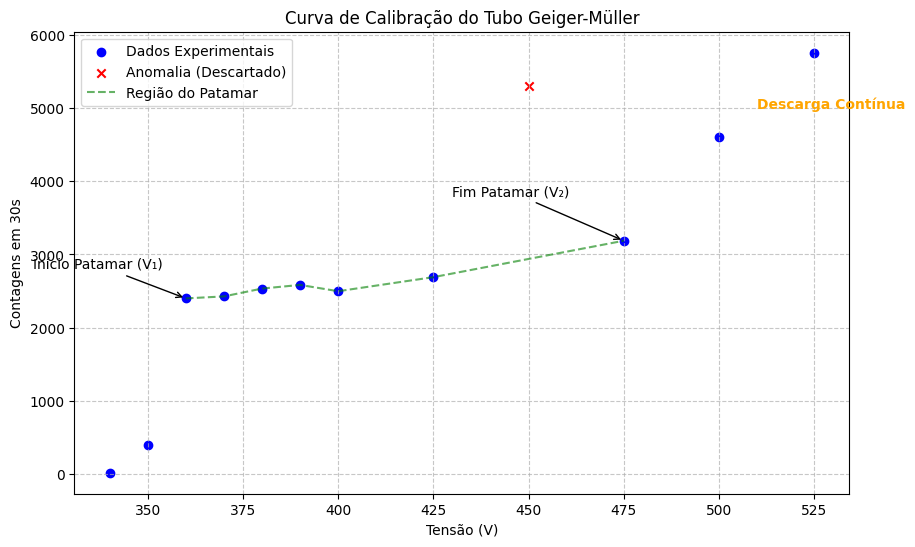

----------------------------------------
ANÁLISE DE DADOS - FONTE 207-Bi
----------------------------------------
Taxa Líquida: 70.348 ± 0.282 cps
Anos decorridos desde 1967: 58.91 anos
Atividade Atual Esperada: 0.3015 µCi (11156.70 Bq)
Eficiência do Sistema: 0.6305 %
----------------------------------------


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
# 1. DADOS E GRÁFICO (CURVA DO TUBO GM)
tensao = np.array([340, 350, 360, 370, 380, 390, 400, 425, 450, 475, 500, 525])
contagens_30s = np.array([20, 396, 2400, 2427, 2534, 2584, 2498, 2690, 5298, 3187, 4597, 5754])
# Máscaras para o gráfico - Descartando a anomalia (450V) e separando a descarga contínua para o gráfico principal
mask_validos = tensao != 450; mask_patamar = (tensao >= 360) & (tensao <= 475) & (tensao != 450);
mask_descarga = tensao >= 500; plt.figure(figsize=(10, 6))
# Plotagem dos pontos
plt.scatter(tensao[mask_validos], contagens_30s[mask_validos], color='blue', label='Dados Experimentais')
plt.scatter(450, 5298, color='red', marker='x', label='Anomalia (Descartado)')
# Linha conectando o patamar
plt.plot(tensao[mask_patamar], contagens_30s[mask_patamar], '--g', alpha=0.6, label='Região do Patamar')
# Destaques
plt.annotate('Início Patamar (V₁)', xy=(360, 2400), xytext=(320, 2800), arrowprops=dict(arrowstyle='->'))
plt.annotate('Fim Patamar (V₂)', xy=(475, 3187), xytext=(430, 3800), arrowprops=dict(arrowstyle='->'))
plt.annotate('Descarga Contínua', xy=(510, 5000), color='orange', fontweight='bold')
plt.title('Curva de Calibração do Tubo Geiger-Müller'); plt.xlabel('Tensão (V)'); plt.ylabel('Contagens em 30s')
plt.grid(True, linestyle='--', alpha=0.7); plt.legend(); plt.show()

# 2. CÁLCULOS: FONTE 207-Bi E EFICIÊNCIA
C_amostra = 63669; t_amostra = 900  # segundos
C_fundo = 237; t_fundo = 600    # segundos
# Taxas de contagem (R = C/t)
R_bruta = C_amostra / t_amostra; R_fundo = C_fundo / t_fundo; R_liquida = R_bruta - R_fundo
# Incerteza
sigma_bruta = np.sqrt(C_amostra) / t_amostra; sigma_fundo = np.sqrt(C_fundo) / t_fundo
sigma_liquida = np.sqrt(sigma_bruta**2 + sigma_fundo**2)

# Atividade Atual do 207-Bi - Meia-vida ~31.55 anos
A0_uCi = 1.1; data_inicial = datetime(1967, 6, 7); data_atual = datetime.now()
anos_decorridos = (data_atual - data_inicial).days / 365.25; t_half = 31.55
atividade_atual_uCi = A0_uCi * np.exp(-np.log(2) * anos_decorridos / t_half) #A = A0 * e^(-ln(2) * t / t_half)
atividade_atual_Bq = atividade_atual_uCi * 37000 #Conversão para Bq (1 uCi = 37000 Bq)
# Eficiência (Eps = R_liquida / Atividade_em_Bq) - geometria 4pi.
eficiencia = (R_liquida / atividade_atual_Bq) * 100

print("-" * 40); print(f"ANÁLISE DE DADOS - FONTE 207-Bi"); print("-" * 40)
print(f"Taxa Líquida: {R_liquida:.3f} ± {sigma_liquida:.3f} cps")
print(f"Anos decorridos desde 1967: {anos_decorridos:.2f} anos")
print(f"Atividade Atual Esperada: {atividade_atual_uCi:.4f} µCi ({atividade_atual_Bq:.2f} Bq)")
print(f"Eficiência do Sistema: {eficiencia:.4f} %"); print("-" * 40)

No ponto de 525V, a correção aumentou a taxa em: 3.99%


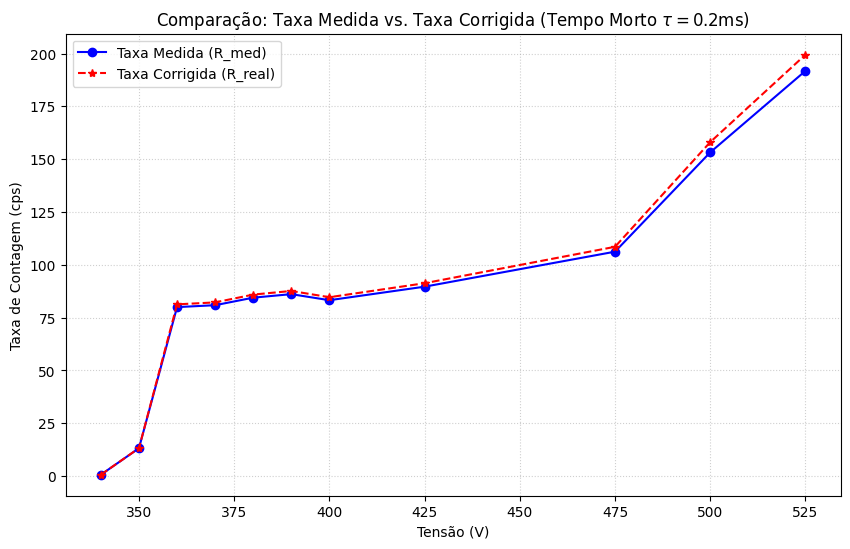

In [4]:
# CORREÇÃO DE TEMPO MORTO E SEGUNDO GRÁFICO
tau = 0.0002  # Tempo morto em segundos (0.2 ms)
taxas_medidas = contagens_30s / 30 # Converter contagens de 30s para taxa cps
taxas_corrigidas = taxas_medidas / (1 - (taxas_medidas * tau)) # R_real = R_medida / (1 - R_medida * tau)
plt.figure(figsize=(10, 6))
plt.plot(tensao[mask_validos], taxas_medidas[mask_validos], 'bo-', label='Taxa Medida (R_med)')
plt.plot(tensao[mask_validos], taxas_corrigidas[mask_validos], 'r*--', label='Taxa Corrigida (R_real)')

plt.title('Comparação: Taxa Medida vs. Taxa Corrigida (Tempo Morto $\\tau = 0.2$ms)')
plt.xlabel('Tensão (V)'); plt.ylabel('Taxa de Contagem (cps)');
plt.grid(True, linestyle=':', alpha=0.6); plt.legend()

dif_percentual = ((taxas_corrigidas[-1] - taxas_medidas[-1]) / taxas_medidas[-1]) * 100
print(f"No ponto de 525V, a correção aumentou a taxa em: {dif_percentual:.2f}%"); plt.show()